# [Centroids (photutils.centroids)](https://photutils.readthedocs.io/en/latest/user_guide/centroids.html)

## Centroid of single source

Let’s extract a single object from a synthetic dataset and find its centroid with each of these methods. First, let’s create the data:

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from photutils.datasets import make_4gaussians_image
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic, centroid_sources)

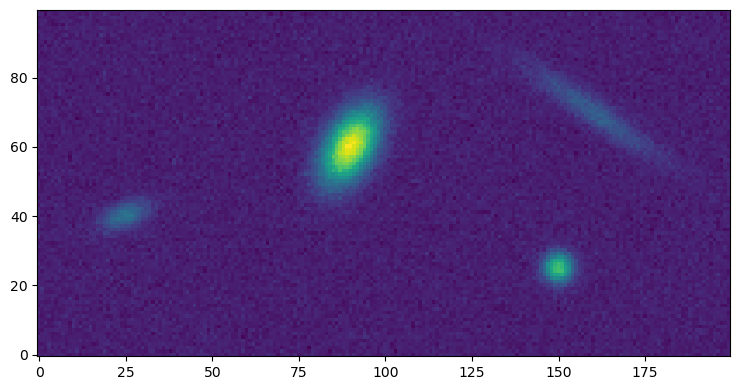

In [19]:
data = make_4gaussians_image()
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(data, origin='lower')
fig.tight_layout()

In [17]:
data = make_4gaussians_image()

Next, we need to subtract the background from the data. For this example, we’ll estimate the background by taking the median of a blank part of the image:

In [8]:
data -= np.median(data[0:30, 0:125])
     # subtrai o fundo: 
    # pega uma região vazia da imagem (pixels [0:30, 0:125]) 
    # e calcula a mediana (valor típico do fundo) 
    # subtrai esse valor de toda a imagem para remover o fundo constante 
    # isso é essencial para o centroide não ser puxado pelo brilho do fundo.

The data is a 2D image of four Gaussian sources. Let’s extract a single object from the data:

In [9]:
data = data[40:80, 70:110]
    # recorta a imagem: 
    # isola apenas uma das fontes ("cutout") em torno da posição conhecida 
    # da fonte (no exemplo, a fonte que está perto da posição (20,20) neste recorte)
    # assim, é trabalhado com uma única fonte de cada vez

Now we can calculate the centroid of the object using each of the centroiding functions:

In [7]:
x1, y1 = centroid_com(data)
print(np.array((x1, y1)))

x2, y2 = centroid_quadratic(data)
print(np.array((x1, y2)))

x3, y3 = centroid_1dg(data)
print(np.array((x3, y3)))

x4, y4 = centroid_2dg(data)
print(np.array((x4, y4)))

[19.9796724  20.00992593]
[19.9796724  20.06884997]
[19.96553246 20.04952841]
[19.9851944  20.01490157]


| Função | Método | Como funciona | Melhor para |
| :---: | :---: | :---: | :---: |
| `centroid_com()` | Centro de massa | Média ponderada pelo fluxo (primeiros momentos da imagem) | Fontes brilhantes e isoladas
| `centroid_quadratic()` | Ajuste quadrático | Ajusta parabolóide 2D (polinômio de 2º grau) | Fontes com perfil próximo a uma parábola |
| `centroid_1dg()` | Gaussiana 1D | Projeta em X/Y e ajusta Gaussianas 1D separadas | Fontes com perfil gaussiano (ver ruído) |
| `centroid_2dg()` | Gaussiana 2D |	Ajusta uma função Gaussiana 2D diretamente aos dados |	O mais preciso para fontes com perfil gaussiano (ex: estrelas) |


The measured centroids are all very close to the object’s true centroid at position `(20, 20)` in the cutout image.

Now let’s plot the results. Because the centroids are all very similar, we also include an inset plot zoomed in near the centroid

(0.0, 39.0)

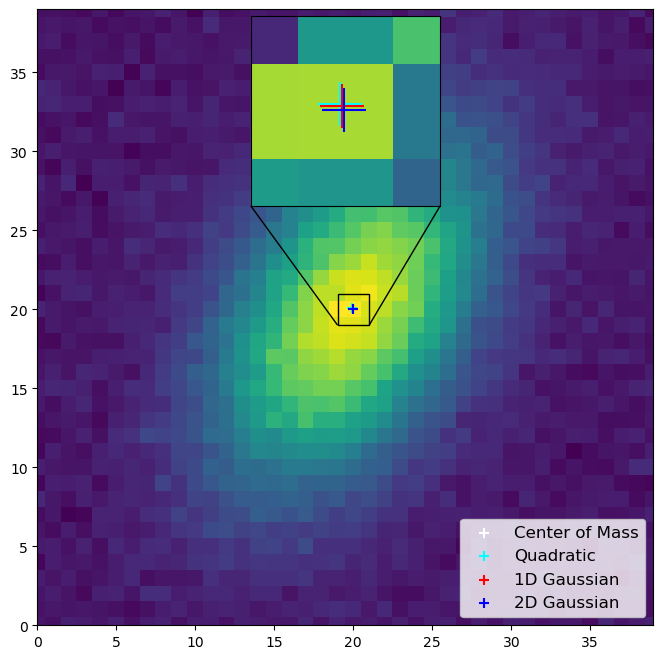

In [22]:
from mpl_toolkits.axes_grid1.inset_locator import (mark_inset,
                                                   zoomed_inset_axes)

data = make_4gaussians_image()
data -= np.median(data[0:30, 0:125])
data = data[40:80, 70:110]
xycen1 = centroid_com(data)
xycen2 = centroid_quadratic(data)
xycen3 = centroid_1dg(data)
xycen4 = centroid_2dg(data)
xycens = [xycen1, xycen2, xycen3, xycen4]
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(data, origin='lower')
marker = '+'
ms = 60
colors = ('white', 'cyan', 'red', 'blue')
labels = ('Center of Mass', 'Quadratic', '1D Gaussian', '2D Gaussian')
for xycen, color, label in zip(xycens, colors, labels, strict=True):
    ax.scatter(*xycen, color=color, marker=marker, s=ms, label=label)

ax.legend(loc='lower right', fontsize=12)

ax2 = zoomed_inset_axes(ax, zoom=6, loc=9)
ax2.imshow(data, vmin=190, vmax=220, origin='lower')
ms = 1000
for xycen, color in zip(xycens, colors, strict=True):
    ax2.scatter(*xycen, color=color, marker=marker, s=ms)
ax2.set_xlim(19, 21)
ax2.set_ylim(19, 21)
mark_inset(ax, ax2, loc1=3, loc2=4, fc='none', ec='black')
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax.set_xlim(0, data.shape[1] - 1)
ax.set_ylim(0, data.shape[0] - 1)

## Centroiding several sources in an image

In [16]:
data -= np.median(data[0:30, 0:125])
x_init = (25, 91, 151, 160)
y_init = (40, 61, 24, 71)
x, y = centroid_sources(data, x_init, y_init, box_size=25,
                        centroid_func=centroid_2dg)

print(x)
print(y)

[ 24.96807815  89.98684653 149.96545722 160.18811079]
[40.03657593 60.01836634 24.96777928 69.80208611]


The measured centroids are all very close to the true centroids of the simulated objects in the image, which have `(x, y)` values of `(25, 40)`, `(90, 60)`, `(150, 25)`, and `(160, 70)`.

Let’s plot the results:

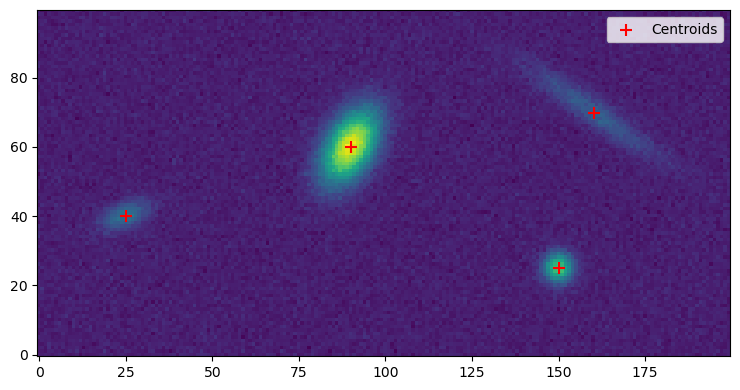

In [21]:
data = make_4gaussians_image()
data -= np.median(data[0:30, 0:125])
x_init = (25, 91, 151, 160)
y_init = (40, 61, 24, 71)
x, y = centroid_sources(data, x_init, y_init, box_size=25,
                        centroid_func=centroid_2dg)
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(data, origin='lower')
ax.scatter(x, y, marker='+', s=80, color='red', label='Centroids')
ax.legend()
fig.tight_layout()